# Amazon Alexa Review - Sentiment Analysis


Analyzing the Amazon Alexa dataset and building classification models to predict if the sentiment of a given input sentence is positive or negative.

In [10]:
%pip install wordcloud
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/99/a1/5219921a9bcb5388623f81908ff43d606aec2e512e0c02f6eb49f3b3caa8/xgboost-2.1.1-py3-none-macosx_12_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# IMPORTING PACKAGES

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import re

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/swatilalwani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# READING THE FILE

In [12]:
df=pd.read_csv('amazon_alexa.tsv',delimiter = '\t', quoting = 3)

# DATA EXPLORATION

In [13]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [18]:
df.shape

(3150, 6)

In [14]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

There are no null values found

In [15]:
df['Length']=df['verified_reviews'].apply(len)

In [16]:
df.head(15)

,rating,date,variation,verified_reviews,feedback,Length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5
5,5,31-Jul-18,Heather Gray Fabric,"""I received the echo as a gift. I needed anoth...",1,174
6,3,31-Jul-18,Sandstone Fabric,"""Without having a cellphone, I cannot use many...",1,367
7,5,31-Jul-18,Charcoal Fabric,I think this is the 5th one I've purchased. I'...,1,221
8,5,30-Jul-18,Heather Gray Fabric,looks great,1,11
9,5,30-Jul-18,Heather Gray Fabric,"""Love it! I’ve listened to songs I haven’t hea...",1,116


The 'length' column is new generated column - stores the length of 'verified_reviews' for that record. Let's check for some sample records

In [23]:
#Randomly checking for 1015th record

print(f"'verified_reviews' column detail: {df.iloc[1015]['verified_reviews']}") #Original value
print(f"Length of review : {len(df.iloc[1015]['verified_reviews'])}") #Length of review using len()


'verified_reviews' column detail: The sound quality is good just wish alexa could answer more questions
Length of review : 69




Datatypes of the features

In [25]:
df.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
Length               int64
dtype: object

rating, feedback and length are integer values
date, variation and verified_reviews are string values

# Analyzing 'rating' column

This column refers to the rating of the variation given by the user

In [27]:
#Distinct values of 'rating' and its count  

print(f"Rating value count: \n{df['rating'].value_counts()}")

Rating value count: 
5    2286
4     455
1     161
3     152
2      96
Name: rating, dtype: int64


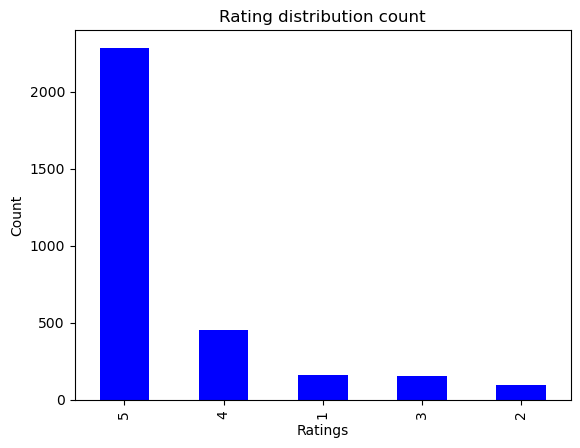

In [28]:
#Bar plot to visualize counts of each rating

df['rating'].value_counts().plot.bar(color = 'blue')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [30]:
#Finding the percentage distribution of each rating - we'll divide the number of records for each rating by total number of records

print(f"Rating value count - percentage distribution: \n{round(df['rating'].value_counts()/df.shape[0]*100,2)}")

Rating value count - percentage distribution: 
5    72.57
4    14.44
1     5.11
3     4.83
2     3.05
Name: rating, dtype: float64


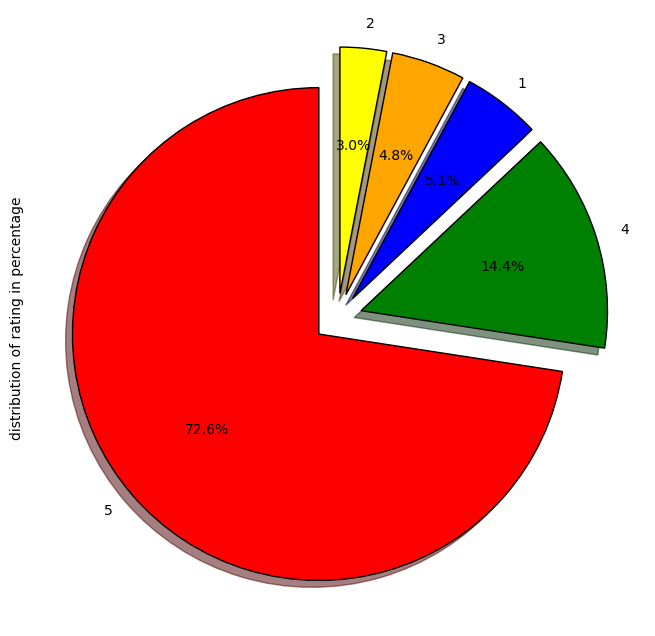

In [41]:
fig = plt.figure(figsize=(9,8))

colors = ('red', 'green', 'blue','orange','yellow')

wp = {'linewidth':1, "edgecolor":'black'}

tags = df['rating'].value_counts()/df.shape[0]

explode=(0.1,0.1,0.1,0.1,0.1)

tags.plot(kind='pie', autopct="%1.1f%%", shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label='distribution of rating in percentage')

from io import  BytesIO

graph = BytesIO()

fig.savefig(graph, format="png")

# Analyzing 'feedback' column

This column refers to the feedback of the verified review

In [34]:
#Distinct values of 'feedback' and its count 

print(f"Feedback value count: \n{df['feedback'].value_counts()}")

Feedback value count: 
1    2893
0     257
Name: feedback, dtype: int64


There are 2 distinct values of 'feedback' present - 0 and 1. 

In [35]:
#Extracting the 'verified_reviews' value for one record with feedback = 0

review_0 = df[df['feedback'] == 0].iloc[1]['verified_reviews']
print(review_0)

Sound is terrible if u want good music too get a bose


In [36]:
#Extracting the 'verified_reviews' value for one record with feedback = 1

review_1 = df[df['feedback'] == 1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


From the above 2 examples we can see that feedback 0 is negative review and 1 is positive review

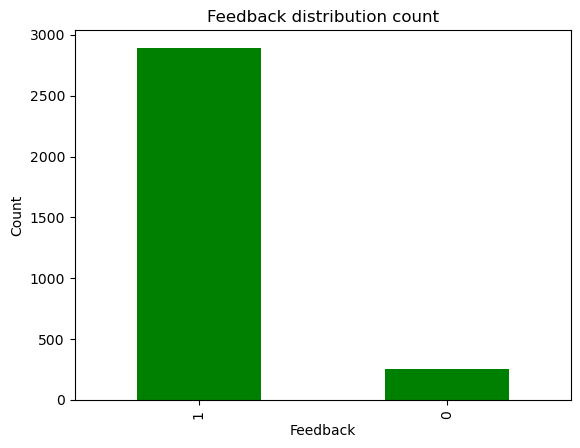

In [37]:
#Bar graph to visualize the total counts of each feedback

df['feedback'].value_counts().plot.bar(color = 'green')
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [38]:
#Finding the percentage distribution of each feedback - we'll divide the number of records for each feedback by total number of records

print(f"Feedback value count - percentage distribution: \n{round(df['feedback'].value_counts()/df.shape[0]*100,2)}")

Feedback value count - percentage distribution: 
1    91.84
0     8.16
Name: feedback, dtype: float64


Feedback distribution

91.87% reviews are positive
8.13% reviews are negative

<Axes: ylabel=' distribution of feedback in percentage'>

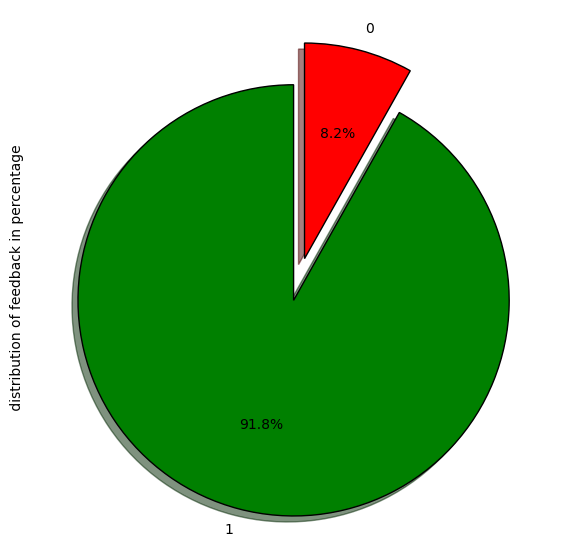

In [40]:
fig = plt.figure(figsize=(7,7))

colors = ('green', 'red')

wp = {'linewidth':1, "edgecolor":'black'}

tags = df['feedback'].value_counts()/df.shape[0]

explode=(0.1,0.1)

tags.plot(kind='pie', autopct="%1.1f%%", shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label=' distribution of feedback in percentage')

In [42]:
#Feedback = 0
df[df['feedback'] == 0]['rating'].value_counts()

1    161
2     96
Name: rating, dtype: int64

In [43]:
#Feedback = 1
df[df['feedback'] == 1]['rating'].value_counts()

5    2286
4     455
3     152
Name: rating, dtype: int64

If rating of a review is 1 or 2 then the feedback is 0 (negative) and if the rating is 3, 4 or 5 then the feedback is 1 (positive).

# Analyzing 'variation' column

This column refers to the variation or type of Amazon Alexa product. Example - Black Dot, Charcoal Fabric etc.

In [44]:
#Distinct values of 'variation' and its count 

print(f"Variation value count: \n{df['variation'].value_counts()}")

Variation value count: 
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
White                            91
Sandstone Fabric                 90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: variation, dtype: int64


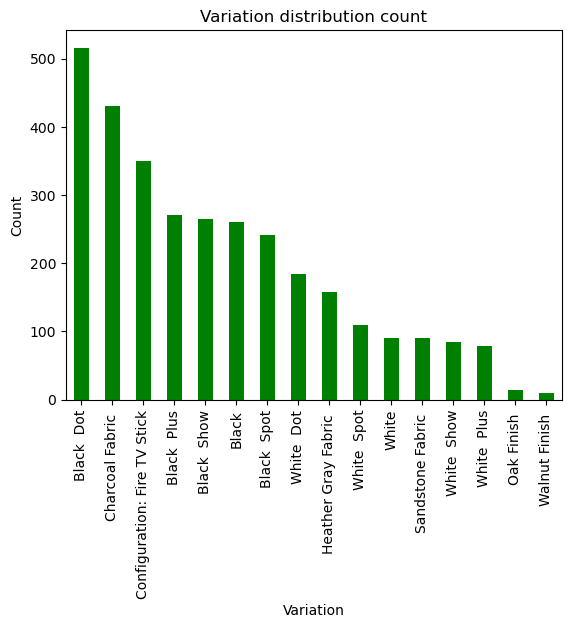

In [45]:
#Bar graph to visualize the total counts of each variation

df['variation'].value_counts().plot.bar(color = 'green')
plt.title('Variation distribution count')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.show()

In [46]:
#Finding the percentage distribution of each variation - we'll divide the number of records for each variation by total number of records

print(f"Variation value count - percentage distribution: \n{round(df['variation'].value_counts()/df.shape[0]*100,2)}")

Variation value count - percentage distribution: 
Black  Dot                      16.38
Charcoal Fabric                 13.65
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.41
Black                            8.29
Black  Spot                      7.65
White  Dot                       5.84
Heather Gray Fabric              4.98
White  Spot                      3.46
White                            2.89
Sandstone Fabric                 2.86
White  Show                      2.70
White  Plus                      2.48
Oak Finish                       0.44
Walnut Finish                    0.29
Name: variation, dtype: float64


In [47]:
df.groupby('variation')['rating'].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.142857
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

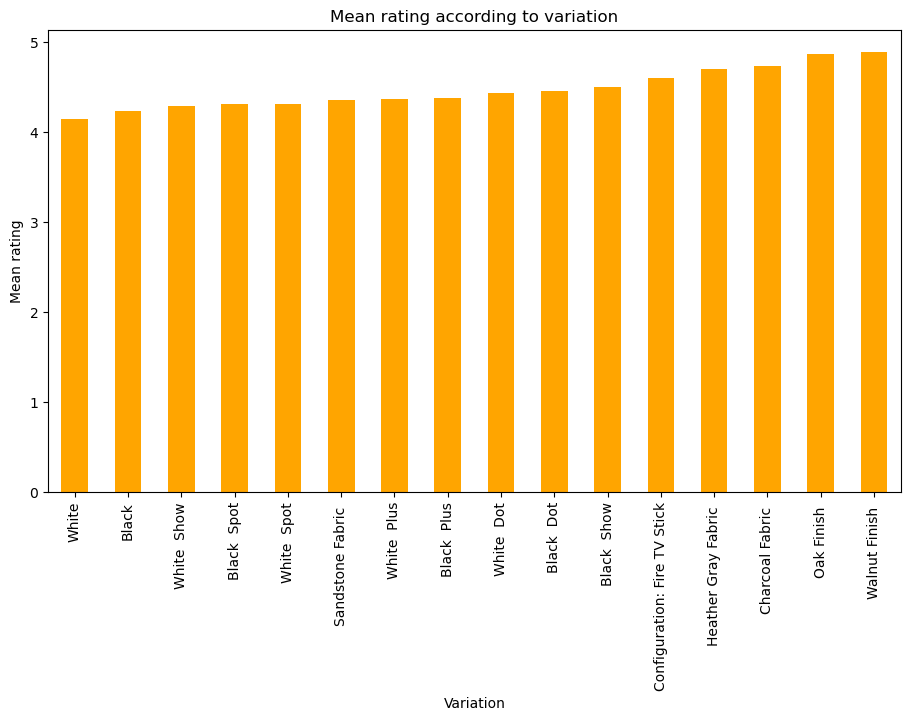

In [48]:
df.groupby('variation')['rating'].mean().sort_values().plot.bar(color = 'orange', figsize=(11, 6))
plt.title("Mean rating according to variation")
plt.xlabel('Variation')
plt.ylabel('Mean rating')
plt.show()

# Analyzing 'verified_reviews' column

This column contains the textual review given by the user for a variation for the product.

In [50]:
df['Length'].describe()

count    3150.000000
mean      132.673651
std       182.526953
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: Length, dtype: float64

[Text(0.5, 1.0, 'Distribution of length of review ')]

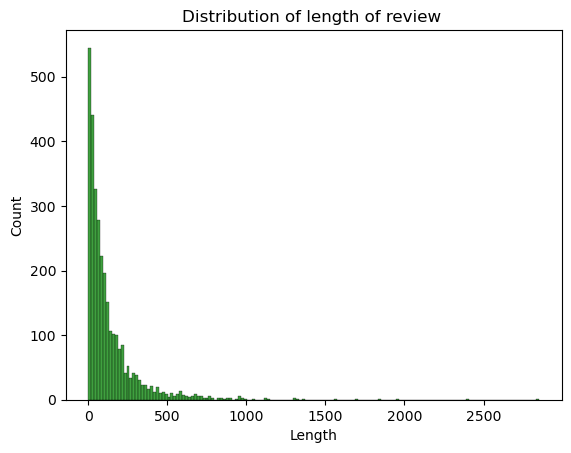

In [51]:
sns.histplot(df['Length'],color='green').set(title='Distribution of length of review ')

Length analysis when feedback is 0 (negative)

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 0')]

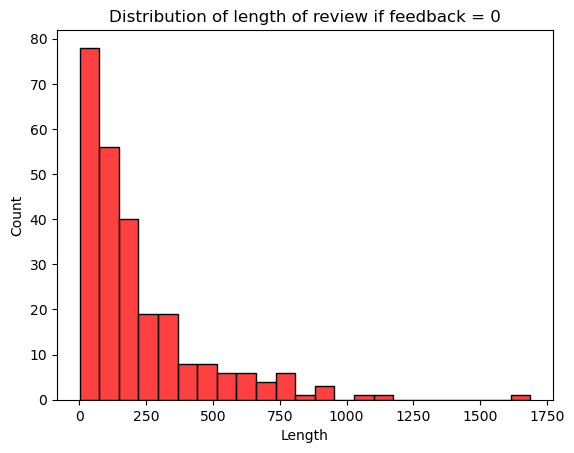

In [53]:
sns.histplot(df[df['feedback']==0]['Length'],color='red').set(title='Distribution of length of review if feedback = 0')

Length analysis when feedback is 1 (positive)

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 1')]

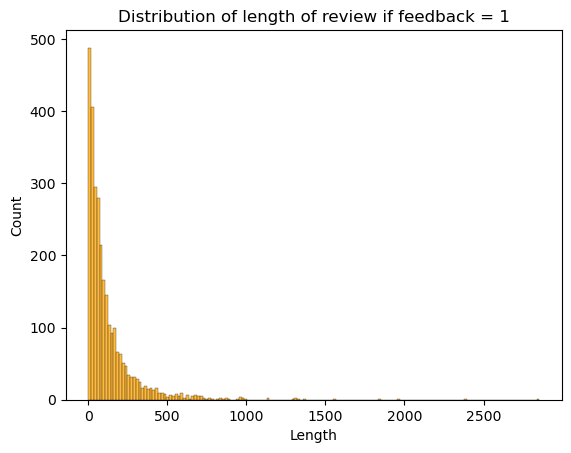

In [54]:
sns.histplot(df[df['feedback']==1]['Length'],color='orange').set(title='Distribution of length of review if feedback = 1')

Lengthwise mean rating

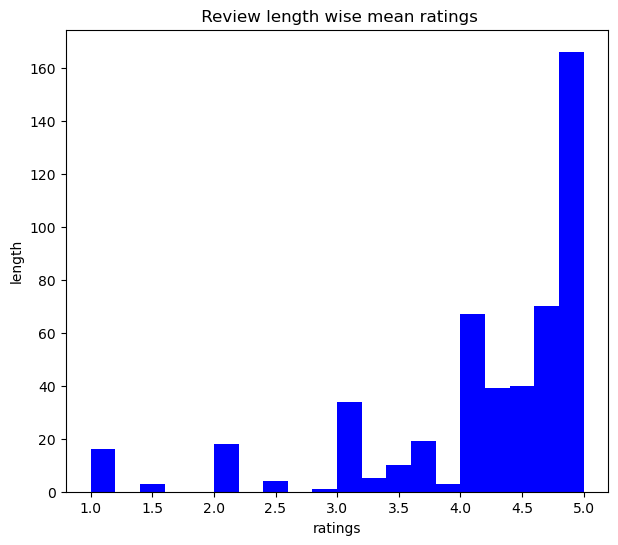

In [55]:
df.groupby('Length')['rating'].mean().plot.hist(color = 'blue', figsize=(7, 6), bins = 20)
plt.title(" Review length wise mean ratings")
plt.xlabel('ratings')
plt.ylabel('length')
plt.show()

In [56]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(df.verified_reviews)

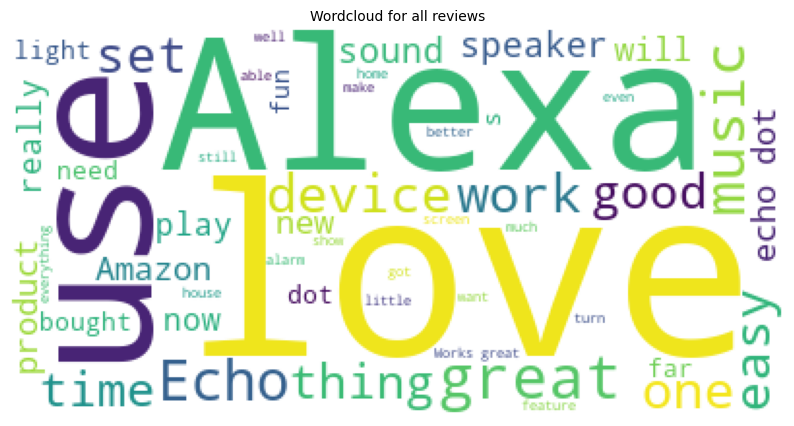

In [58]:
# Combine all reviews
reviews = " ".join([review for review in df['verified_reviews']])
                        
# Initialize wordcloud object
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('Wordcloud for all reviews', fontsize=10)
plt.axis('off')
plt.show()

Finding Unique words for each category

In [59]:
# Combine all reviews for each feedback category and splitting them into individual words
neg_reviews = " ".join([review for review in df[df['feedback'] == 0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in df[df['feedback'] == 1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

#Finding words from reviews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)

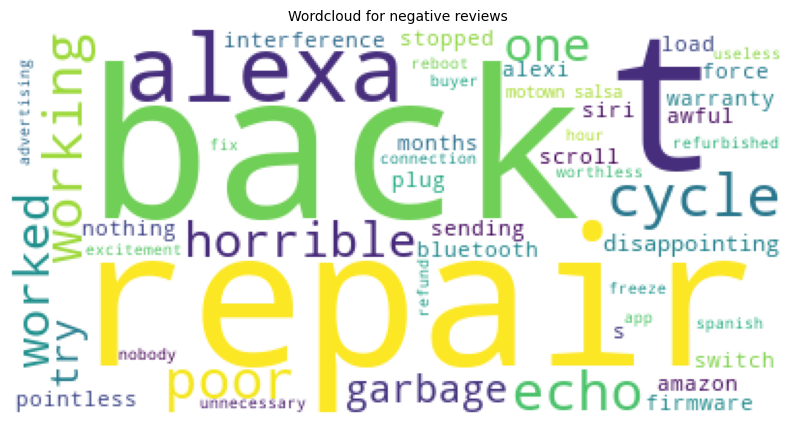

In [60]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews', fontsize=10)
plt.axis('off')
plt.show()

Negative words can be seen in the above word cloud - garbage, pointless, poor, horrible, repair etc

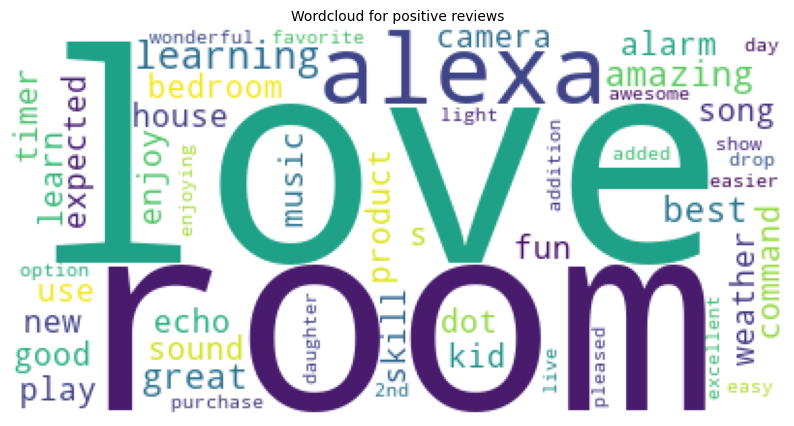

In [61]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for positive reviews', fontsize=10)
plt.axis('off')
plt.show()

Positive words can be seen in the above word cloud - good, enjoying, amazing, best, great etc

# DATA Preprocessing

To build the corpus from the 'verified_reviews' we perform the following -

Replace any non alphabet characters with a space
Covert to lower case and split into words
Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus

In [62]:
corpus = []
stemmer = PorterStemmer()
for i in range(0, df.shape[0]):
  review = re.sub('[^a-zA-Z]', ' ', df.iloc[i]['verified_reviews'])
  review = review.lower().split()
  review = [stemmer.stem(word) for word in review if not word in STOPWORDS]
  review = ' '.join(review)
  corpus.append(review)

Using Count Vectorizer to create bag of words means converting categorical data to numerical data in NLP

In [73]:
cv = CountVectorizer(max_features = 2500)

#Storing independent and dependent variables in X and y
x = cv.fit_transform(corpus).toarray()
y = df['feedback'].values

In [74]:
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (3150, 2500)
y shape: (3150,)


# TRAIN_TEST_SPLIT

Splitting data into train and test set with 50% data with testing.

In [75]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.5, random_state = 15)

print(f"X train: {x_train.shape}")
print(f"y train: {y_train.shape}")
print(f"X test: {x_test.shape}")
print(f"y test: {y_test.shape}")

X train: (1575, 2500)
y train: (1575,)
X test: (1575, 2500)
y test: (1575,)


In [77]:
print(f"X train max value: {x_train.max()}")
print(f"X test max value: {x_test.max()}")

X train max value: 12
X test max value: 10


We'll scale X_train and X_test so that all values are between 0 and 1.

In [79]:
scaler = MinMaxScaler()

x_train_scl = scaler.fit_transform(x_train)
x_test_scl = scaler.transform(x_test)

# Random Forest

In [80]:
#Fitting scaled X_train and y_train on Random Forest Classifier
model_rf = RandomForestClassifier()
model_rf.fit(x_train_scl, y_train)

RandomForestClassifier()

In [81]:
#Accuracy of the model on training and testing data
 
print("Training Accuracy :", model_rf.score(x_train_scl, y_train))
print("Testing Accuracy :", model_rf.score(x_test_scl, y_test))

Training Accuracy : 0.9942857142857143
Testing Accuracy : 0.932063492063492


In [82]:
#Predicting on the test set
y_preds = model_rf.predict(x_test_scl)

In [83]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_preds)

In [84]:
cm

array([[  33,   94],
       [  13, 1435]])

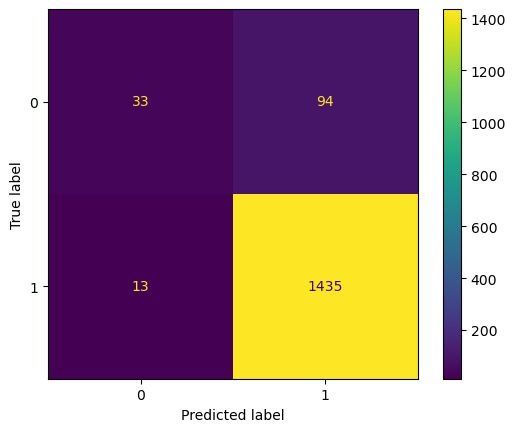

In [85]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_rf.classes_)
cm_display.plot()
plt.show()

# K-FOLD CROSS VALIDATION

In [88]:
accuracies = cross_val_score(estimator = model_rf, X = x_train_scl, y = y_train, cv = 10)

print("Accuracy :", accuracies.mean())
print("Standard Variance :", accuracies.std())

Accuracy : 0.932693703136338
Standard Variance : 0.008163406304316835


Applying grid search cv to get the optimal parameters on random forest

In [89]:
params = {
    'bootstrap': [True],
    'max_depth': [80, 100],
    'min_samples_split': [8, 12],
    'n_estimators': [100, 300]
}

In [91]:
cv_object = StratifiedKFold(n_splits = 2)

grid_search = GridSearchCV(estimator = model_rf, param_grid = params, cv = cv_object, verbose = 0, return_train_score = True)
grid_search.fit(x_train_scl, y_train.ravel())

GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'max_depth': [80, 100],
                         'min_samples_split': [8, 12],
                         'n_estimators': [100, 300]},
             return_train_score=True)

In [92]:
#Getting the best parameters from the grid search


print("Best Parameter Combination : {}".format(grid_search.best_params_))

Best Parameter Combination : {'bootstrap': True, 'max_depth': 100, 'min_samples_split': 8, 'n_estimators': 100}


In [93]:

print("Cross validation mean accuracy on train set : {}".format(grid_search.cv_results_['mean_train_score'].mean()*100))
print("Cross validation mean accuracy on test set : {}".format(grid_search.cv_results_['mean_test_score'].mean()*100))
print("Accuracy score for test set :", accuracy_score(y_test, y_preds))

Cross validation mean accuracy on train set : 97.41257643238153
Cross validation mean accuracy on test set : 92.17461009810435
Accuracy score for test set : 0.932063492063492


# XgBoost

In [95]:
model_xgb = XGBClassifier()
model_xgb.fit(x_train_scl, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [96]:
#Accuracy of the model on training and testing data
 
print("Training Accuracy :", model_xgb.score(x_train_scl, y_train))
print("Testing Accuracy :", model_xgb.score(x_test_scl, y_test))

Training Accuracy : 0.9771428571428571
Testing Accuracy : 0.9282539682539682


In [97]:
y_preds = model_xgb.predict(x_test)

In [100]:
#Confusion Matrix
cm1= confusion_matrix(y_test, y_preds)


In [101]:
cm1

array([[  45,   82],
       [  33, 1415]])

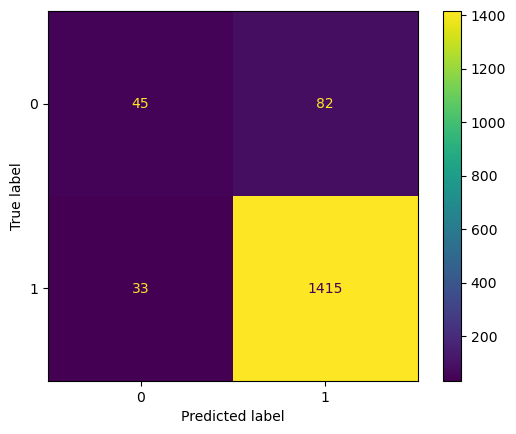

In [102]:
cm1_display = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=model_xgb.classes_)
cm1_display.plot()
plt.show()

# Decision tree Classifier

In [103]:
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train_scl, y_train)

DecisionTreeClassifier()

In [104]:
#Accuracy of the model on training and testing data
 
print("Training Accuracy :", model_dt.score(x_train_scl, y_train))
print("Testing Accuracy :", model_dt.score(x_test_scl, y_test))

Training Accuracy : 0.9942857142857143
Testing Accuracy : 0.8990476190476191


In [105]:
y_preds = model_dt.predict(x_test)

In [106]:
#Confusion Matrix
cm2= confusion_matrix(y_test, y_preds)


In [107]:
cm2

array([[  65,   62],
       [ 224, 1224]])

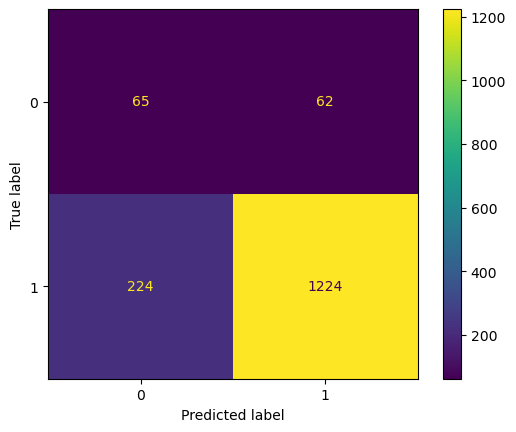

In [108]:
cm2_display = ConfusionMatrixDisplay(confusion_matrix=cm2,display_labels=model_dt.classes_)
cm2_display.plot()
plt.show()